In [1]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

Grayscale
=========
Code source: OTUS IT https://www.youtube.com/watch?v=zGW3Cr-q2w8

(400, 400, 3)


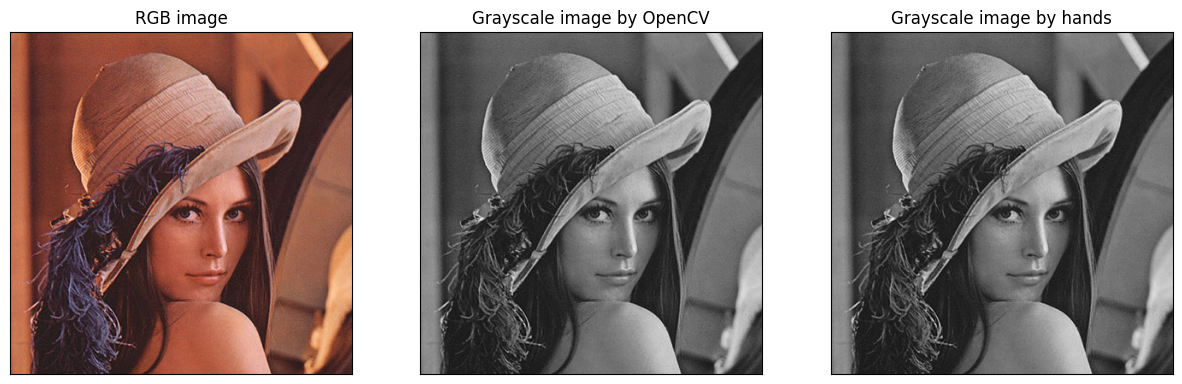

Equal: True


In [2]:
plt.rcParams['figure.figsize'] = [15, 10]
img_path = 'data/lena.png'

# Открываем изображение:
img_bgr = cv.imread(img_path)
print(img_bgr.shape)

# BGR -> Grayscale (OpenCV):
img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)      # cv.COLOR_GRAY2BGR, cv.COLOR_RGB2BGR

# BRG -> Grayscale (вручную):                           # RGB to GRAY: 0.299⋅R + 0.587⋅G + 0.114⋅B              
img_gray2 = img_bgr[...,0]*0.114 + \
            img_bgr[...,1]*0.587 + \
            img_bgr[...,2]*0.299
img_gray2 = np.rint(img_gray2).astype(np.uint8)         # округляем float и преобразуем в uint8

# [...,::-1] выполняет инверсию порядка каналов
plt.subplot(2,3,1), plt.imshow(img_bgr[...,::-1]), plt.title("RGB image")
plt.xticks([]),plt.yticks([])
plt.subplot(2,3,2), plt.imshow(img_gray,'gray'), plt.title('Grayscale image by OpenCV')
plt.xticks([]),plt.yticks([])
plt.subplot(2,3,3), plt.imshow(img_gray2,'gray'), plt.title('Grayscale image by hands')
plt.xticks([]),plt.yticks([])
plt.show()

print('Equal:', np.array_equal(img_gray, img_gray2))

Пример размытия изображения (blur, GaussianBlur)
=========

🟡 2) Пример размытия изображения (blur, GaussianBlur)

✅ Подробный урок с кодом «Image blurring using OpenCV»
👉 https://www.geeksforgeeks.org/python/python-image-blurring-using-opencv/

💡 Важно запомнить
Фильтр	Параметры
GaussianBlur	(kernel_x, kernel_y), sigma
medianBlur	одно нечётное число

🔥 Маленький совет по CV
GaussianBlur → хорошо убирает шум
medianBlur → отлично убирает salt-and-pepper шум
medianBlur медленнее, но лучше сохраняет границы

📌 Ниже пример:



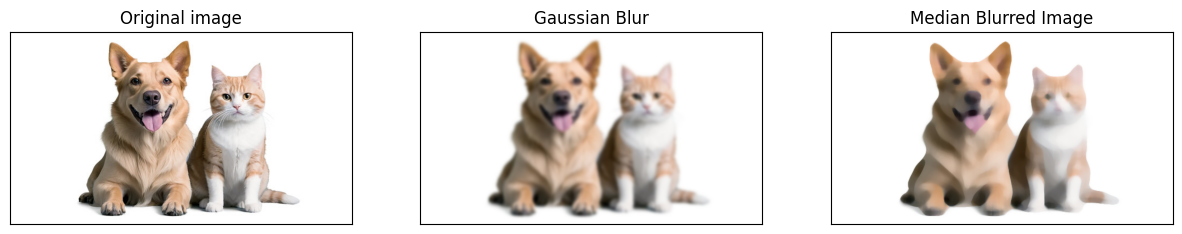

In [21]:
image = cv.imread('data/dog-cat.jpg')
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB) 
blurred = cv.GaussianBlur(image, (15, 15), 0)
median = cv.medianBlur(image, 15)
median_rgb = cv.cvtColor(median, cv.COLOR_BGR2RGB)  

plt.figure(figsize=(15,5))  # ширина, высота в дюймах
plt.subplot(1,3,1), plt.imshow(image_rgb), plt.title("Original image")
plt.xticks([]),plt.yticks([])
plt.subplot(1,3,2), plt.imshow(cv.cvtColor(blurred, cv.COLOR_BGR2RGB)), plt.title('Gaussian Blur')
plt.xticks([]),plt.yticks([])
plt.subplot(1,3,3), plt.imshow(median_rgb), plt.title('Median Blurred Image')
plt.xticks([]),plt.yticks([])
plt.show()

Пример по Canny
=========

📌 подробный пример по Canny

🔗 Edge Detection Using OpenCV — official blog (Python code)
https://opencv.org/blog/edge-detection-using-opencv/


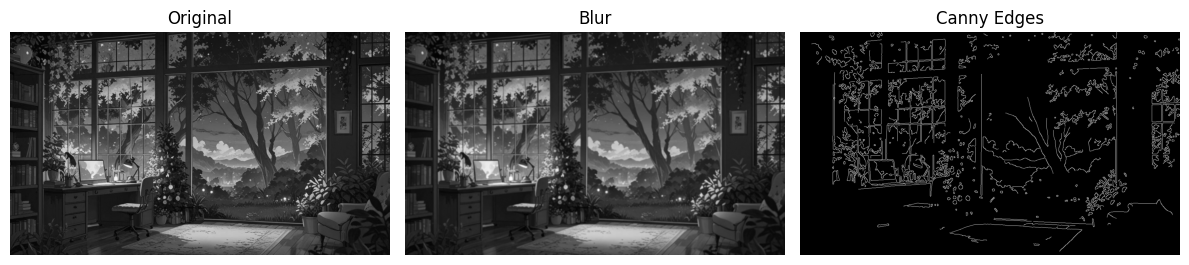

In [2]:
img = cv.imread("data/exampleimage.JPG", cv.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError("Изображение не найдено. Проверьте путь.")

blur = cv.GaussianBlur(img, (5,5), 1.4)
edges = cv.Canny(blur, 100, 200)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(blur, cmap="gray")
plt.title("Blur")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()